In [5]:
#import required classes and packages
import pandas as pd
import numpy as np
import pickle, os
from Attention import attention #loadig attention layer
from keras_dgl.layers import GraphCNN #loading GNN class
import keras.backend as K
from keras.regularizers import l2
from keras.utils.np_utils import to_categorical
from keras.layers import Dense, Dropout, Activation, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from keras.models import Sequential, load_model
import warnings
warnings.filterwarnings('ignore')

In [6]:
#loading & displaying twitter_spammer dataset
dataset = pd.read_csv("Dataset/twitter_spammer.csv")
dataset = dataset.replace([np.inf, -np.inf], np.nan)
dataset

,NumberOfFollowings,NumberOfFollowers,NumberOfTweets,AccountAge,no_userfavourites,no_retweets,no_statuses,spammer
0,3269,3071,861,1217,0.939431,0.707477,0.335000,1
1,1949,793,226,1329,0.406875,0.170053,0.272727,1
2,1119,9644,38674,1272,8.618409,30.404088,0.553299,1
3,2174,6029,12718,1105,2.773229,11.509502,0.445000,1
4,7731,7029,873,1105,0.909197,0.790045,0.105000,1
...,...,...,...,...,...,...,...,...
39806,172,3,2,0,0.017442,NaN,1.000000,0
39807,5,0,5,0,0.000000,NaN,0.000000,0
39808,20,1,1,0,0.050000,NaN,0.000000,0
39809,20,1,1,0,0.050000,NaN,0.000000,0


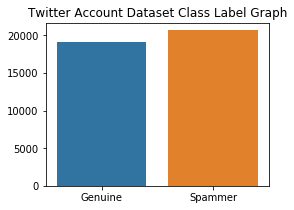

In [7]:
#graphs of different PCOS diagnosis labels available in dataset
unique, count = np.unique(dataset['spammer'], return_counts=True)
labels = ['Genuine', 'Spammer']
plt.figure(figsize=(4, 3))
sns.barplot(x=labels, y=count)
plt.title("Twitter Account Dataset Class Label Graph")
plt.show() 

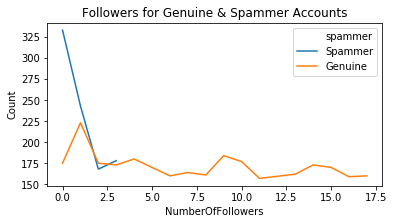

In [8]:
data = dataset.groupby(["NumberOfFollowers","spammer"])['spammer'].count().sort_values(ascending=False).reset_index(name='Count')[0:20]
data['spammer'] = data['spammer'].replace(0, 'Genuine')
data['spammer'] = data['spammer'].replace(1, 'Spammer')
plt.figure(figsize=(6, 3))
sns.lineplot(data=data, x="NumberOfFollowers", y="Count",hue="spammer")
plt.title("Followers for Genuine & Spammer Accounts")
plt.show()

In [9]:
#handling missing values and then extracting X and Y features from dataset and then shuffling and normalizing training features
dataset.dropna(inplace = True)
Y = dataset[['spammer']].mean(axis=1)
Y = Y.ravel()
dataset.drop(['spammer'], axis = 1,inplace=True)
X = dataset.values
scaler = MinMaxScaler(feature_range = (0, 1))
X = scaler.fit_transform(X) #normalizing features
#shuffling features at random position
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]
print("Normalized Training Features = "+str(X))

Normalized Training Features = [[3.55618126e-03 1.20667934e-05 6.27760720e-05 ... 3.99872041e-06
  2.57657284e-04 2.45362646e-03]
 [4.96402680e-03 1.36215533e-04 1.91752366e-03 ... 3.23609680e-05
  1.44279184e-03 5.67169935e-05]
 [1.82837083e-03 4.15376158e-05 1.78683529e-02 ... 2.67078714e-05
  7.66174286e-03 7.27775105e-03]
 ...
 [4.83878340e-02 1.11942714e-03 5.93233881e-03 ... 2.73278626e-05
  6.31360786e-03 5.64334086e-05]
 [6.22651686e-01 1.50410259e-02 4.33925331e-02 ... 2.85400002e-05
  1.43011690e-02 1.07787810e-02]
 [3.94928099e-03 3.31836819e-05 1.22698686e-04 ... 9.90445182e-06
  3.21923493e-02 0.00000000e+00]]


In [10]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Train & Test Dataset Split")
print("80% records used to train algorithms : "+str(X_train.shape[0]))
print("20% records features used to test algorithms : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Train & Test Dataset Split
80% records used to train algorithms : 30700
20% records features used to test algorithms : 7676


In [11]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [12]:
#function to evaluate model
def modelEvaluation(algorithm, testY, predict):
    p = round(precision_score(testY, predict,average='macro') * 100, 2)
    r = round(recall_score(testY, predict,average='macro') * 100, 2)
    f = round(f1_score(testY, predict,average='macro') * 100, 2)
    a = round(accuracy_score(testY,predict)*100, 2)
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 

    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()

Random Forest Accuracy  : 71.57
Random Forest Precision : 78.26
Random Forest Recall    : 73.1
Random Forest FSCORE    : 70.59


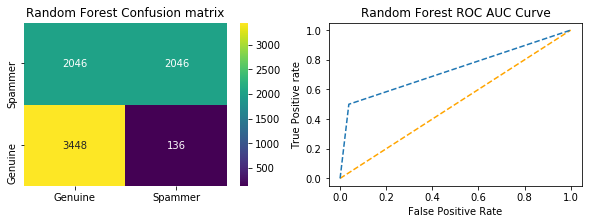

In [13]:
#training Random Forest algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
rf_cls = RandomForestClassifier(max_depth=1)
#train model on training features
rf_cls.fit(X_train[0:9], y_train[0:9])
#call this function to predict on test data
predict = rf_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Random Forest", y_test, predict)

MLP Accuracy  : 77.53
MLP Precision : 77.57
MLP Recall    : 77.21
MLP FSCORE    : 77.3


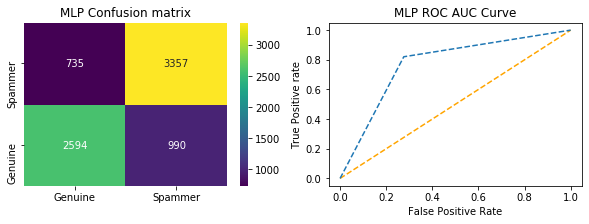

In [14]:
#training MLP algorithm on 80% training features and then apply trained model on 20% test to calculate prediction accuracy
mlp_cls = MLPClassifier()
if os.path.exists("model/mlp.pckl"):
    f = open('model/mlp.pckl', 'rb')
    mlp_cls = pickle.load(f)
    f.close() 
else:
    mlp_cls.fit(X_train[0:1000], y_train[0:1000])
    f = open('model/mlp.pckl', 'wb')
    pickle.dump(mlp_cls, f)
    f.close()  
predict = mlp_cls.predict(X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("MLP", y_test, predict)


Propose GNN with Attention Accuracy  : 87.3
Propose GNN with Attention Precision : 87.52
Propose GNN with Attention Recall    : 87.61
Propose GNN with Attention FSCORE    : 87.3


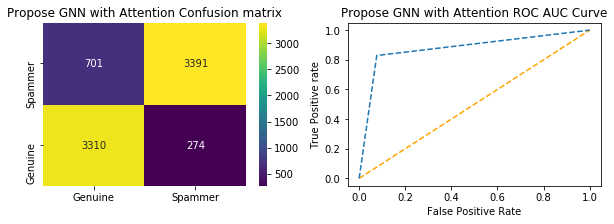

In [15]:
#Create GNN model to detect spam
y_train1 = to_categorical(y_train)
y_test1 = to_categorical(y_test)
graph_conv_filters = np.eye(1)
graph_conv_filters = K.constant(graph_conv_filters)
gnn_model = Sequential()
#adding GNN layer with 128 neurons to filter dataset 
gnn_model.add(GraphCNN(128, 1, graph_conv_filters, input_shape=(X_train.shape[1],), activation='elu', kernel_regularizer=l2(5e-4)))
gnn_model.add(GraphCNN(64, 1, graph_conv_filters, input_shape=(X_train.shape[1],), activation='elu', kernel_regularizer=l2(5e-4)))
gnn_model.add(GraphCNN(1, 1, graph_conv_filters, input_shape=(X_train.shape[1],), activation='elu', kernel_regularizer=l2(5e-4)))
#adding attention layer to GNN
gnn_model.add(attention(return_sequences=True,name='attention'))
gnn_model.add(Dense(units = 256, activation = 'elu'))
gnn_model.add(Dense(units = y_train1.shape[1], activation = 'softmax'))
gnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/gnn_weights.hdf5") == False:
    hist = gnn_model.fit(X_train, y_train1, batch_size=1, epochs=40, validation_data = (X_test, y_test1), verbose=1)
    gnn_model.save_weights("model/gnn_weights.hdf5")
else:
    gnn_model.load_weights("model/gnn_weights.hdf5")
#perform prediction on test data and then calculate accuracy and other metrics
pred = []
for i in range(len(X_test)):
    temp = []
    temp.append(X_test[i])
    temp = np.asarray(temp)
    predict = gnn_model.predict(temp, batch_size=1)
    predict = np.argmax(predict)
    pred.append(predict)
y_test2 = np.argmax(y_test1, axis=1)    
predict = np.asarray(pred)
#call this function to calculate accuracy and other metrics
modelEvaluation("Propose GNN with Attention", y_test2, predict)

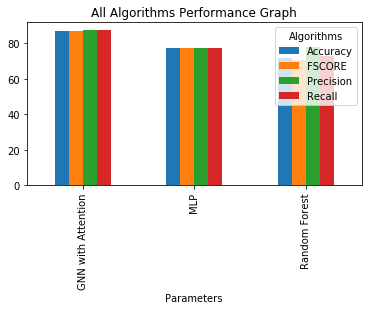

In [16]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['Random Forest','Accuracy',accuracy[0]],['Random Forest','Precision',precision[0]],['Random Forest','Recall',recall[0]],['Random Forest','FSCORE',fscore[0]],
                   ['MLP','Accuracy',accuracy[1]],['MLP','Precision',precision[1]],['MLP','Recall',recall[1]],['MLP','FSCORE',fscore[1]],
                   ['GNN with Attention','Accuracy',accuracy[2]],['GNN with Attention','Precision',precision[2]],['GNN with Attention','Recall',recall[2]],['GNN with Attention','FSCORE',fscore[2]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [17]:
#display all algorithm performnace
algorithms = ['Random Forest','MLP','GNN with Attention']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Random Forest,71.57,78.26,73.10,70.59
1,MLP,77.53,77.57,77.21,77.30
2,GNN with Attention,87.30,87.52,87.61,87.30


In [18]:
#loading test data and then applying extension model to predict type of attack
testData = pd.read_csv("Dataset/testData.csv")#load test data
data = testData.copy()
testData.fillna(0, inplace = True)#replace misisng values with mean    
testData = testData.values    
testData = scaler.transform(testData)#normalize test data
pred = []
for i in range(len(testData)): #loop each test
    temp = []
    temp.append(testData[i])
    temp = np.asarray(temp)
    predict = gnn_model.predict(temp, batch_size=1)#apply GNN model on test data to predict spammer or genuine account
    predict = np.argmax(predict)
    pred.append(labels[predict])
pred = np.asarray(pred)
data['GNN Account Prediction'] = pred
data = data.style.set_properties(**{'background-color': 'yellow'}, subset=['GNN Account Prediction'])
data

,Followings,Followers,total_Tweets,AccountAge,no_userfavourites,no_retweets,no_statuses,GNN Account Prediction
0,62,69,2620,374,1.112903,7.005348,0.395000,Genuine
1,163,250,11660,373,1.533742,31.260054,0.515000,Genuine
2,9027,9950,428,583,1.102249,0.734134,0.018987,Spammer
3,484,132,827,476,0.272727,1.737395,0.189474,Genuine
4,1290,314,220,434,0.243411,0.506912,0.115000,Spammer
5,61,49,95,371,0.803279,0.256065,0.021053,Genuine
6,196,123,470,371,0.627551,1.266846,0.155000,Genuine
7,171,5068,7376,372,29.637427,19.827957,0.975000,Genuine
8,5713,6446,1774,609,1.128304,2.912972,0.000000,Spammer
9,10148,9239,596,519,0.910426,1.148362,0.025000,Spammer
